In [1]:
import os
from pathlib import Path
from dataclasses import dataclass
from functools import cached_property

import MDAnalysis as mda
from MDAnalysis.analysis import rms
import numpy as np
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
import matplotx
import seaborn as sns
from tqdm import tqdm
import pymbar 

from utils import write_view_system_frame_pml
%matplotlib

Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.

********* JAX NOT FOUND *********
 PyMBAR can run faster with JAX  
 But will work fine without it   
Either install with pip or conda:
      pip install pybar[jax]     
               OR                
      conda install pymbar       
*********************************


Using matplotlib backend: module://matplotlib_inline.backend_inline


In [2]:
@dataclass
class ConvexHullFrame:
    volume: float
    coords: np.ndarray
    vertex_indices: np.ndarray
    simplices: np.ndarray

class ConvexHullTrajectory():
    """
    path_to_trajectories: Path to directory containing trajectory files (e.g. .xtc), must be compatible with the topology file
    path_to_topology: Path to topology file (e.g. .pdb, .gro) compatible with the trajectory files
    residue_selection: List of tuples specifying residues to include in convex hull calculation, where each tuple is (residue_id, segment_id)
    """
    def __init__(self, path_to_trajectories: Path, path_to_topology: Path, residue_selection: list[tuple[int, str]]):
        self.path_to_trajectories = path_to_trajectories
        self.path_to_topology = path_to_topology
        self.residue_selection = residue_selection
        self._trajectories = sorted([x for x in path_to_trajectories.iterdir() if x.match('*.xtc')])
        self.universe = mda.Universe(self.path_to_topology, self._trajectories)
        self.residue_atoms = self.universe.select_atoms(" or ".join([f"(resid {resid} and segid {segid})" for resid, segid in self.residue_selection]))
        #self.residue_atoms_only_heavy_sidechains = self.residue_atoms.select_atoms("not name H* and not backbone")
        self.residue_atoms_only_heavy_sidechains = self.residue_atoms.select_atoms("not name H*")
    
    @cached_property
    def hulls(self):
        """
        Compute the convex hull formed from selected side chain heavy atoms for each frame of the trajectory and store the results in a list.
        """
        hulls = []

        for ts in tqdm(self.universe.trajectory):
            coords = self.residue_atoms_only_heavy_sidechains.positions
            hull = ConvexHull(coords)
            hulls.append(
                 ConvexHullFrame(
                            volume = hull.volume,
                            coords = coords,
                            vertex_indices = hull.vertices.copy(),
                            simplices = hull.simplices.copy()
                 )
            )

        return hulls
    
    # def plot_volume_over_time(self, title: str) -> None:
    #     hull_volumes = [hull.volume for hull in self.hulls]
    #     plt.plot(hull_volumes)
    #     plt.xlabel('Frame')
    #     plt.ylabel('Volume (Å³)')
    #     plt.title(f'{title}')
    #     plt.savefig(self.path_to_trajectories / f'{title.replace(" ", "_")}.png')
    #     print("Plot saved to:", self.path_to_trajectories / f'{title.replace(" ", "_")}.png')
    #     plt.show()


    def plot_volume_over_time(self, title: str) -> None:
        # Raw pocket volumes
        hull_volumes = [hull.volume for hull in self.hulls]

        # Running average (1 ns = 100 frames at 10 ps/frame)
        window = 100
        average_1ns = [
            np.mean(hull_volumes[i:i+window])
            for i in range(len(hull_volumes) - window + 1)
        ]

        # Frame indices
        frames_raw = np.arange(len(hull_volumes))
        frames_avg = np.arange(window - 1, len(hull_volumes))
        frame_to_ns = lambda frame: frame * 10 / 1000 # 10 ps per frame, convert to ns
        raw_frames_as_ns = np.array([frame_to_ns(i) for i in frames_raw])
        avg_frames_as_ns = np.array([frame_to_ns(i) for i in frames_avg])


        # Seaborn styling
        sns.set(style="white", context="talk")

        # Plot
        plt.figure(figsize=(12, 6))

        # Raw data: transparent
        sns.lineplot(
            x=raw_frames_as_ns,
            y=hull_volumes,
            alpha=0.25,
            linewidth=1.2,
            label="Hull volume"
        )

        # Running average: solid
        sns.lineplot(
            x=avg_frames_as_ns,
            y=average_1ns,
            linewidth=2.5,
            label="1 ns running average"
        )

        plt.xlabel("Time (ns)")
        plt.ylabel("Volume (Å³)")
        plt.title(f"{title}")

        plt.legend()
        plt.tight_layout()
  
        plt.savefig(self.path_to_trajectories / f'{title.replace(" ", "_")}.png')
        print("Plot saved to:", self.path_to_trajectories / f'{title.replace(" ", "_")}.png')
        plt.show()

    def write_convex_hull_frame_pdb(self, hull_frame: ConvexHullFrame, output_path: Path | None = None) -> None:
        """
        Write a single convex hull frame to a PDB file, including vertex coordinates and connectivity.
        """
        if output_path is None:
            output_path = self.path_to_trajectories / "hull_frame.pdb"

        coords = hull_frame.coords
        vertex_indices = hull_frame.vertex_indices
        simplices = hull_frame.simplices

        vertex_set = set(vertex_indices)

        # original coord index -> pdb atom index
        index_map = {}

        with open(output_path, "w") as f:

            pdb_index = 1

            # write hull vertices only
            for original_idx in vertex_indices:

                point = coords[original_idx]

                f.write(
                    f"HETATM{pdb_index:5d}  C   BOX A   1"
                    f"{point[0]:12.3f}"
                    f"{point[1]:8.3f}"
                    f"{point[2]:8.3f}"
                    f"  1.00  0.00           C\n"
                )

                index_map[original_idx] = pdb_index
                pdb_index += 1

            # build unique edge list from simplices
            edges = set()

            for tri in simplices:

                for i, j in [(0, 1), (1, 2), (2, 0)]:

                    a = tri[i]
                    b = tri[j]

                    if a in vertex_set and b in vertex_set:

                        edge = tuple(sorted((a, b)))
                        edges.add(edge)

            # write connectivity
            for a, b in edges:

                f.write(
                    f"CONECT"
                    f"{index_map[a]:5d}"
                    f"{index_map[b]:5d}\n"
                )

            f.write("END\n")

        print(f"Wrote hull PDB to: {output_path}")

    def write_system_frame_pdb(self, frame_index: int, output_path: Path | None = None) -> None:
        """
        Write the full system for a given frame index to a PDB file and also write the corresponding convex hull frame to a separate PDB file.
        """
        if output_path is None:
            output_path = self.path_to_trajectories / f"frame_{frame_index}.pdb"

        with mda.Writer(output_path, multiframe=False) as writer:
            self.universe.trajectory[frame_index]
            writer.write(self.universe)

        print(f"Wrote system frame {frame_index} to PDB: {output_path}")

        self.write_convex_hull_frame_pdb(hull_frame=self.hulls[frame_index], 
                                         output_path=output_path.with_name(f"hull_frame_{frame_index}.pdb"))
        write_view_system_frame_pml(residue_selection=self.residue_selection, output_path=output_path, frame_index=frame_index)


In [3]:
CWD = Path(os.getcwd()).parent

paths = {
    '4h2i': CWD / '4h2i' / 'unbiased',
    '4h2i_noadn': CWD / '4h2i_noadn' / 'unbiased',
    '4h2g': CWD / '4h2g' / 'unbiased',
    '4h2g_noadn': CWD / '4h2g_noadn' / 'unbiased',
    '6tve': CWD / '6tve' / 'unbiased',
    '6twa': CWD / '6twa' / 'unbiased',
}

# Residues implicated in docking poses, 

BINDING_SITE_RESIDUES_onlyRahimova2018 = [
    (366, "A"), (456, "B"), (543, "A"), (543, "B"),                                         # Major H-bond ints in top hits, Fig 6 Rahimova 2018 and text  
    (473, "A"), (473, "B"), (545, "A"), (545, "B"), (471, "A"),                             # Charged residues with non bonding ints, described in text
    (455, "A"), (542, "A"),                                                                 # H-bond ints in Fig 6 with RR6, RR4
    (453, "A"), (453, "B"), (454, "A"), (454, "B"), (544, "A"), (544, "B"),                 # Glycines hydrophobic described in text, Fig 7
]

BINDING_SITE_RESIDUES = [
    (366, "A"), (456, "B"), (543, "A"), (543, "B"), (484, "A"), (484, "B"), (547, "B"),     # Major H-bond ints in top hits, Fig 6 Rahimova 2018 and text  
    (473, "A"), (473, "B"), (545, "A"), (545, "B"), (471, "A"),                             # Charged residues with non bonding ints, described in text
    (455, "A"), (542, "A"),                                                                 # H-bond ints in Fig 6 with RR6, RR4
    (453, "A"), (453, "B"), (454, "A"), (454, "B"), (544, "A"), (544, "B"),                 # Glycines hydrophobic described in text, Fig 7
    (366, "A"), (531, "A"),                                                                 # D366 makes H-bond, Y531 Pi-stack (Grosjean 2025)    
]

# All residues on C-terminal domain interface selected in PyMol through (4 Angstrom A-B chain distance)
# select C_A, (frame_0 and chain A and resi 337-549)
# select C_B, (frame_0 and chain B and resi 337-549)
# select ifaceA, byres (C_A within 4.0 of C_B)
# select ifaceB, byres (C_B within 4.0 of C_A)

# INTERFACE_RESIDUES_5ANGSTROM = [
#     (343, 'A'), (344, 'A'), (345, 'A'), (346, 'A'), (347, 'A'), (352, 'A'), (358, 'A'), 
#     (359, 'A'), (366, 'A'), (369, 'A'), (370, 'A'), (373, 'A'), (374, 'A'), (375, 'A'), 
#     (376, 'A'), (380, 'A'), (381, 'A'), (382, 'A'), (400, 'A'), (456, 'A'), (475, 'A'), 
#     (480, 'A'), (481, 'A'), (482, 'A'), (483, 'A'), (484, 'A'), (531, 'A'), (534, 'A'), 
#     (535, 'A'), (536, 'A'), (537, 'A'), (539, 'A'), (540, 'A'), (541, 'A'), (542, 'A'), 
#     (543, 'A'), (544, 'A'), (547, 'A'), 
#     (343, 'B'), (344, 'B'), (345, 'B'), (347, 'B'), (352, 'B'), (358, 'B'), (359, 'B'), 
#     (366, 'B'), (369, 'B'), (370, 'B'), (373, 'B'), (374, 'B'), (376, 'B'), (380, 'B'), 
#     (381, 'B'), (382, 'B'), (400, 'B'), (403, 'B'), (456, 'B'), (471, 'B'), (473, 'B'), 
#     (475, 'B'), (479, 'B'), (480, 'B'), (481, 'B'), (482, 'B'), (483, 'B'), (484, 'B'), 
#     (531, 'B'), (534, 'B'), (535, 'B'), (536, 'B'), (537, 'B'), (539, 'B'), (540, 'B'), 
#     (541, 'B'), (542, 'B'), (543, 'B'), (544, 'B'), (547, 'B')]

INTERFACE_RESIDUES = [
    (343, 'A'), (344, 'A'), (345, 'A'), (347, 'A'), (359, 'A'), (366, 'A'), (369, 'A'), 
    (370, 'A'), (373, 'A'), (381, 'A'), (382, 'A'), (400, 'A'), (456, 'A'), (475, 'A'), 
    (480, 'A'), (481, 'A'), (482, 'A'), (483, 'A'), (484, 'A'), (535, 'A'), (536, 'A'), 
    (537, 'A'), (539, 'A'), (540, 'A'), (541, 'A'), (542, 'A'), (543, 'A'), (544, 'A'), 
    (547, 'A'), 
    (343, 'B'), (344, 'B'), (345, 'B'), (347, 'B'), (359, 'B'), (366, 'B'), (369, 'B'), 
    (370, 'B'), (373, 'B'), (381, 'B'), (382, 'B'), (400, 'B'), (456, 'B'), (471, 'B'), 
    (475, 'B'), (480, 'B'), (481, 'B'), (482, 'B'), (483, 'B'), (484, 'B'), (534, 'B'), 
    (537, 'B'), (539, 'B'), (540, 'B'), (541, 'B'), (542, 'B'), (543, 'B'), (547, 'B')
]



In [7]:
allosteric_bindingsite_trajectories = {
        "4h2i": ConvexHullTrajectory(paths["4h2i"], paths["4h2i"] / "nosol.pdb", BINDING_SITE_RESIDUES),
        "4h2i_noadn": ConvexHullTrajectory(paths["4h2i_noadn"], paths["4h2i_noadn"] / "nosol.pdb", BINDING_SITE_RESIDUES),
        "4h2g": ConvexHullTrajectory(paths["4h2g"], paths["4h2g"] / "nosol.pdb", BINDING_SITE_RESIDUES),
        "4h2g_noadn": ConvexHullTrajectory(paths["4h2g_noadn"], paths["4h2g_noadn"] / "nosol.pdb", BINDING_SITE_RESIDUES),
        "6tve": ConvexHullTrajectory(paths["6tve"], paths["6tve"] / "nosol.pdb", BINDING_SITE_RESIDUES),
        "6twa": ConvexHullTrajectory(paths["6twa"], paths["6twa"] / "nosol.pdb", BINDING_SITE_RESIDUES)
}

allosteric_bindingsite_trajectories_oldselection = {
        "4h2i": ConvexHullTrajectory(paths["4h2i"], paths["4h2i"] / "nosol.pdb", BINDING_SITE_RESIDUES_onlyRahimova2018),
        "4h2i_noadn": ConvexHullTrajectory(paths["4h2i_noadn"], paths["4h2i_noadn"] / "nosol.pdb", BINDING_SITE_RESIDUES_onlyRahimova2018),
        "4h2g": ConvexHullTrajectory(paths["4h2g"], paths["4h2g"] / "nosol.pdb", BINDING_SITE_RESIDUES_onlyRahimova2018),
        "4h2g_noadn": ConvexHullTrajectory(paths["4h2g_noadn"], paths["4h2g_noadn"] / "nosol.pdb", BINDING_SITE_RESIDUES_onlyRahimova2018),
        "6tve": ConvexHullTrajectory(paths["6tve"], paths["6tve"] / "nosol.pdb", BINDING_SITE_RESIDUES_onlyRahimova2018),
        "6twa": ConvexHullTrajectory(paths["6twa"], paths["6twa"] / "nosol.pdb", BINDING_SITE_RESIDUES_onlyRahimova2018)
}

interface_trajectories = {
        "4h2i": ConvexHullTrajectory(paths["4h2i"], paths["4h2i"] / "nosol.pdb", INTERFACE_RESIDUES),
        "4h2i_noadn": ConvexHullTrajectory(paths["4h2i_noadn"], paths["4h2i_noadn"] / "nosol.pdb", INTERFACE_RESIDUES),
        "4h2g": ConvexHullTrajectory(paths["4h2g"], paths["4h2g"] / "nosol.pdb", INTERFACE_RESIDUES),
        "4h2g_noadn": ConvexHullTrajectory(paths["4h2g_noadn"], paths["4h2g_noadn"] / "nosol.pdb", INTERFACE_RESIDUES),
        "6tve": ConvexHullTrajectory(paths["6tve"], paths["6tve"] / "nosol.pdb", INTERFACE_RESIDUES),
        "6twa": ConvexHullTrajectory(paths["6twa"], paths["6twa"] / "nosol.pdb", INTERFACE_RESIDUES)
}

/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/MDAnalysis/topology/PDBParser.py:376: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "


Binding site residues were chosen based on Figures and docking pose / SAR analyses found in the three papers from the Peyrottes group at the Univ. of Montpellier: 
1. Rahimova 2018 (doi.org/10.1371/journal.pcbi.1005943.g007).
2. Ghoteimi 2023 (doi.org/10.1002/cmdc.202200594)
3. Grosjean 2025 (doi.org/10.1002/cmdc.202400662)

| Residue | Interaction type | Description |
| --- | --- | --- |
| D366 B | H-bond with COO- | Fig 6 (Rahimova 2018). |
| H456 B | H-bond with N | Fig 6 (Rahimova 2018). |
| Y484 A | H-bond with -OH | Fig 6, H-bond with central scaffold N's with RR6, RR11 (Rahimova 2018).  | 
| Y484 B | H-bond with -OH | Fig 6: Makes H-Bond with sulfone RR16 (Rahimova 2018). Fig 3: Makes H-bond with central scaffold cyano group nitrogen (Ghoteimi 2023)
| E543 A | H-bond with COO- | Fig 6, text describes all hits two interact with one or more E543's (Rahimova 2018) |
| E543 B | H-bond with COO- | Fig 6, idem (Rahimova 2018) |
| D473 A | ... | Described in text as forming non-bonded interactions, charged (Rahimova 2018) |
| D473 B | ... | idem, not clear which chain (Rahimova 2018) |
| R545 A | ... | idem, not clear which chain (Rahimova 2018) |
| R545 B | ... | idem, not clear which chain (Rahimova 2018) |
| K471 A | H-bond with amino | Fig 6, H-bond with terminal end of ligand RR6 (Rahimova 2018) |
| I455 A | H-bond with backbone carbonyl, hydrophobic in text | Figure 6 H-bond with central scaffold N of RR4 (Rahimova 2018) |
| K547 B | H-bond with amino | Fig 3: H-bonding with phenyl methoxy's or morpholino groups at the terminal ends of the R groups (Ghoteimi 2023) |
| V452 A | Hydrophobic | Fig 6 (Rahimova 2018) |
| G453 A | Hydrophobic | text, Fig 7, unclear which chain (Rahimova 2018) |
| G453 B | Hydrophobic | idem (Rahimova 2018) |
| G454 A | Hydrophobic | idem (Rahimova 2018) |
| G454 B | Hydrophobic | idem (Rahimova 2018) |
| G455 A | Hydrophobic | idem (Rahimova 2018) |
| G455 B | Hydrophobic | idem (Rahimova 2018) | 
| G544 A | Hydrophobic | idem (Rahimova 2018) |
| G544 B | Hydrophobic | idem (Rahimova 2018) |



# Experimental CD73 structures
There are several high-resolution CD73 structures available in the PDB. The two series below were chosen because of the availability of both closed/open conformations in the same experimental source and high resolution.

`6TVE` (open, 1.05 A), `6TWA` (closed, 2.00 A) are a pair of CD73 structures crystallized without endogenous ligand.
- Some multiple rotamers in `6TWA` (occupancies < 1), but were located far away from dimer interface. The highest occupancy rotamers were kept during protein preparation.
- Lys 457 is observed to have low electron density in the `6TWA` structure at its long flexible side chain, this was also observed with the other closed structure `4H2I`; nevertheless, the two structures showed good overlap at the dimer interface.

`4H2G` (open), `4H2I` (closed) are a pair of CD73 structures crystallized with ADN/AMP derivative AMPCP in the orthosteric binding site, from Knapp 2012.
- In the first (of 3) paper from Univ. of Montpellier, the source of the CD73 allosteric PPI inhibitor ligands, Rahimova 2018, Targeted Molecular Dynamics was performed to force to open-closed transition with the `4H2G`, `4H2I` structures using RMSD-based TMD. From this trajectory, several conformers were extracted for ensemble docking. Endogenous AMP was placed by aligning its structure with the crystallized AMPCP.
- In the second paper (Ghoteimi 2023), it was not mentioned which CD73 structure was used, just that flexible docking was used to analyze binding poses of experimental hits.
- In the third paper (Grossjean 2025), `4H2I` was used; docking box defined as 15A sphere around Glu 543.

100%|██████████| 50005/50005 [01:13<00:00, 681.57it/s]


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/4h2i/unbiased/4h2i_Binding_Site_(Old_Rahimova2018_Selection)_Convex_Hull_Volume_Over_Time.png


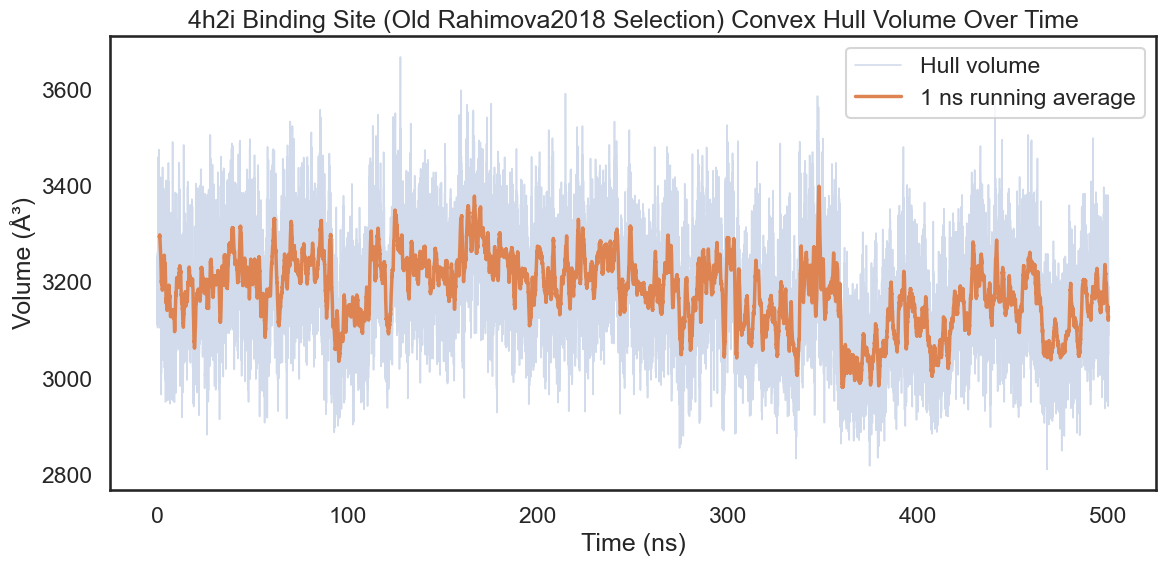

100%|██████████| 50006/50006 [01:15<00:00, 663.30it/s]


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/4h2i_noadn/unbiased/4h2i_noadn_Binding_Site_(Old_Rahimova2018_Selection)_Convex_Hull_Volume_Over_Time.png


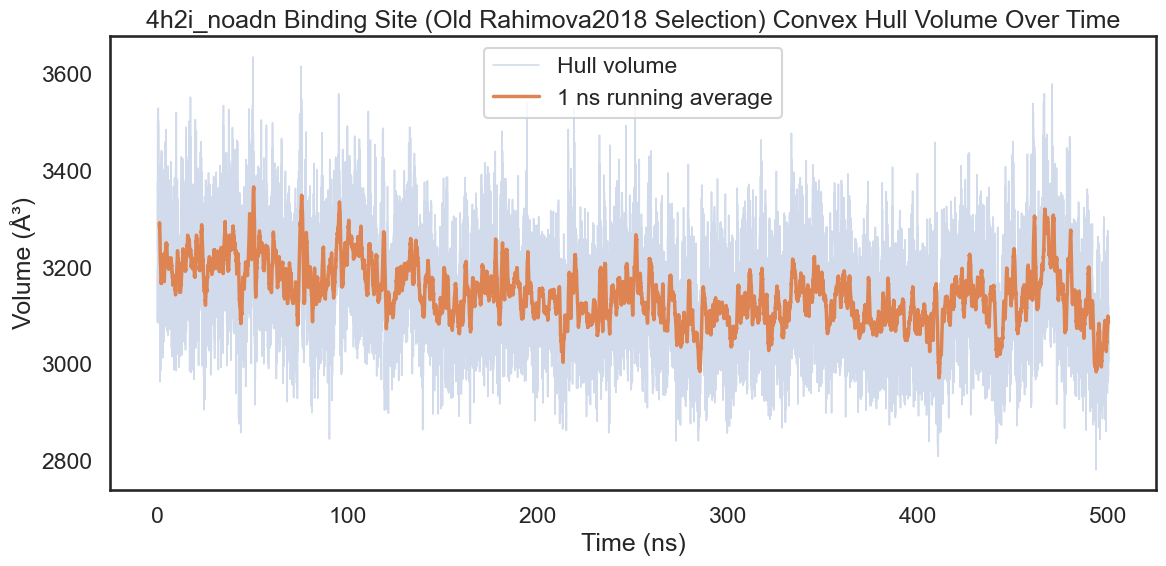

100%|██████████| 30003/30003 [00:40<00:00, 747.52it/s]


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/4h2g/unbiased/4h2g_Binding_Site_(Old_Rahimova2018_Selection)_Convex_Hull_Volume_Over_Time.png


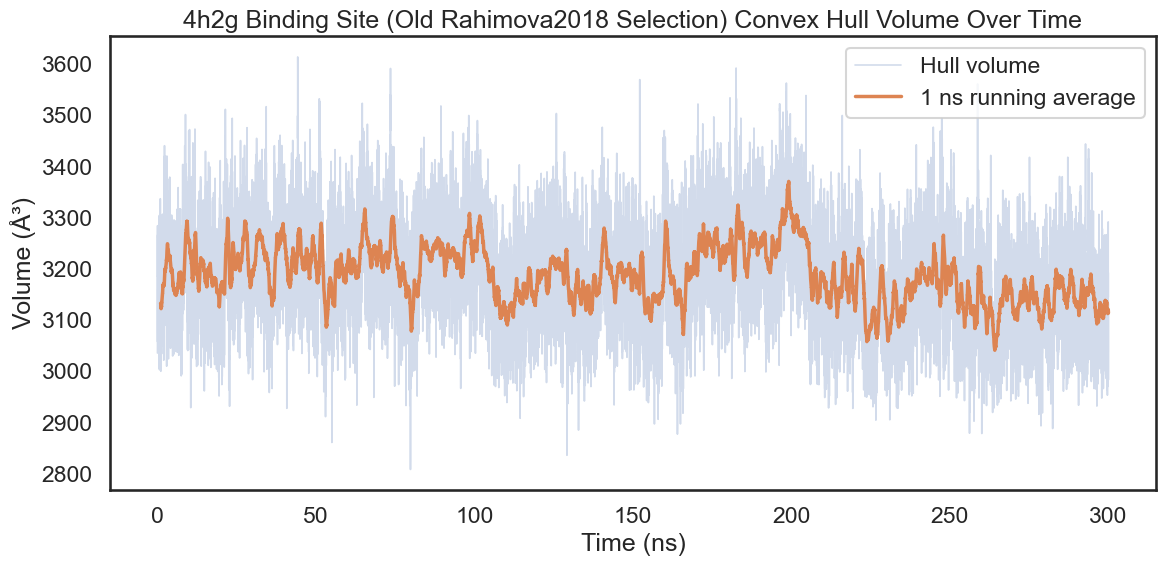

100%|██████████| 21892/21892 [00:31<00:00, 687.42it/s]


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/4h2g_noadn/unbiased/4h2g_noadn_Binding_Site_(Old_Rahimova2018_Selection)_Convex_Hull_Volume_Over_Time.png


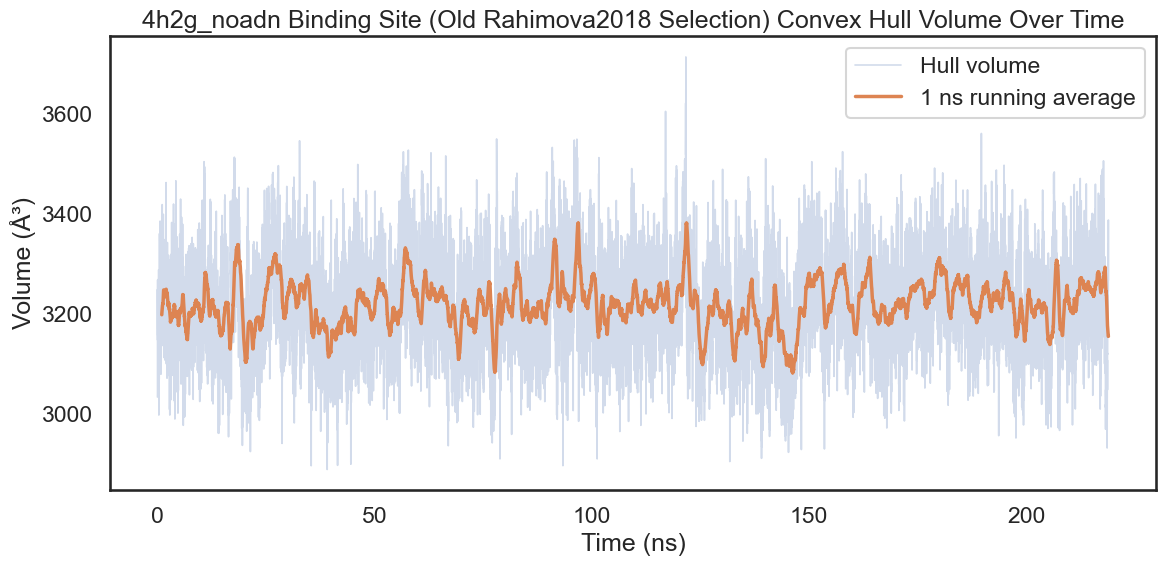

100%|██████████| 50006/50006 [01:12<00:00, 688.43it/s]


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/6tve/unbiased/6tve_Binding_Site_(Old_Rahimova2018_Selection)_Convex_Hull_Volume_Over_Time.png


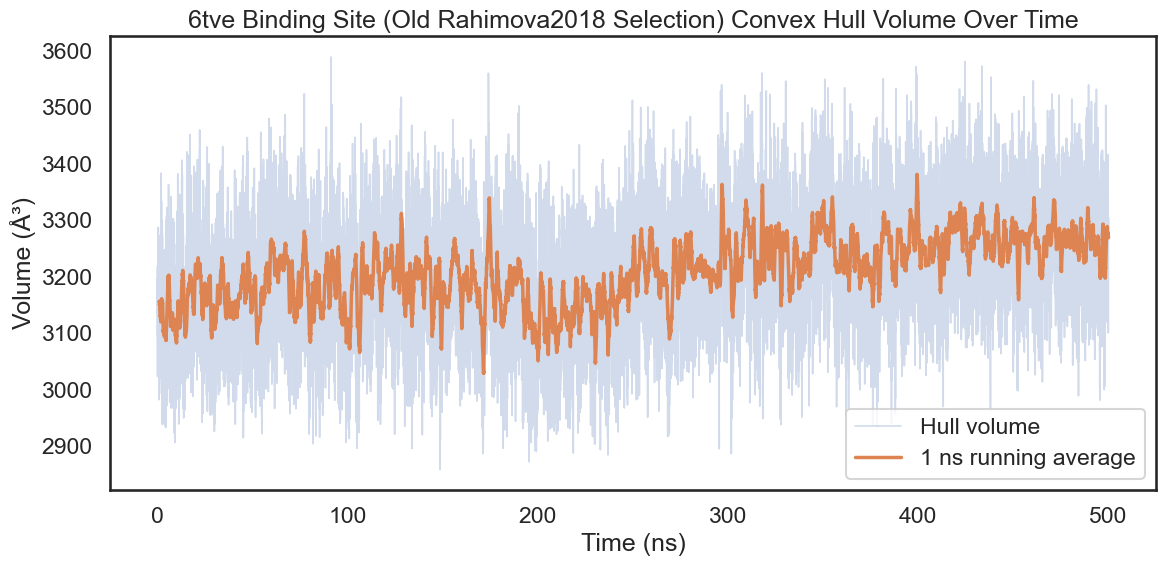

100%|██████████| 20002/20002 [00:32<00:00, 609.39it/s]


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/6twa/unbiased/6twa_Binding_Site_(Old_Rahimova2018_Selection)_Convex_Hull_Volume_Over_Time.png


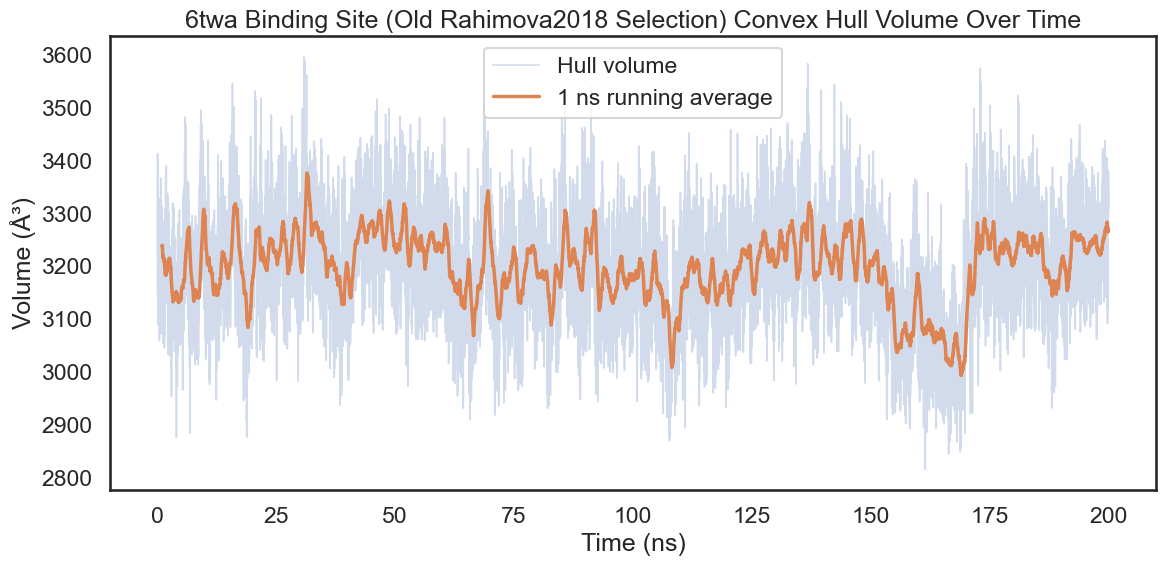

In [8]:
for name, traj in allosteric_bindingsite_trajectories_oldselection.items():
    traj.plot_volume_over_time(title=f"{name} Binding Site (Old Rahimova2018 Selection) Convex Hull Volume Over Time")

100%|██████████| 50005/50005 [01:24<00:00, 594.83it/s]


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/4h2i/unbiased/4h2i_Binding_Site_(All_Residues)_Convex_Hull_Volume_Over_Time.png


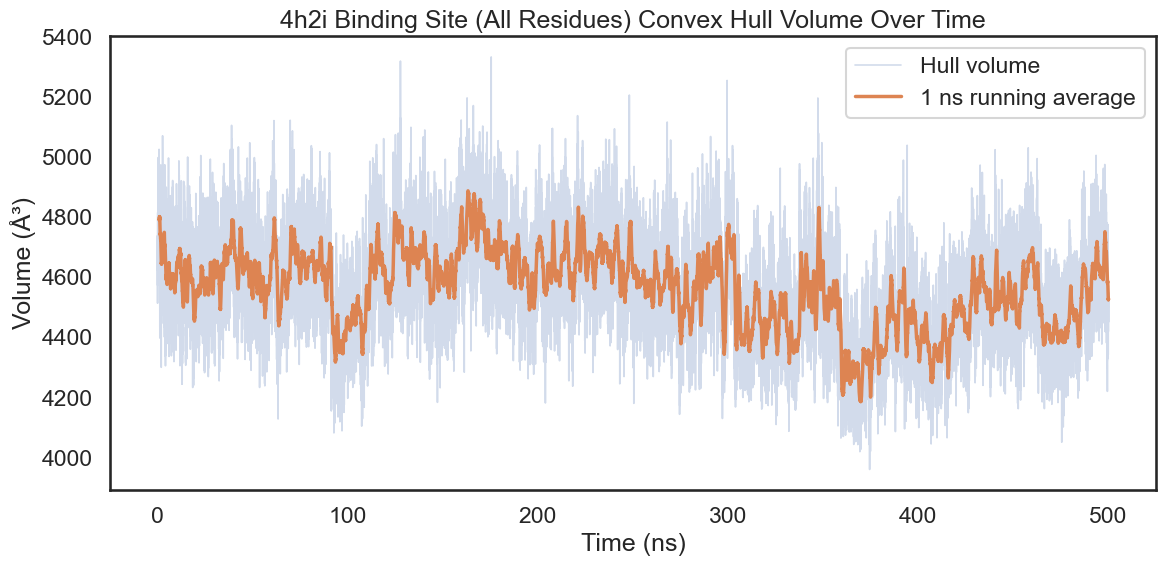

100%|██████████| 50006/50006 [01:22<00:00, 609.25it/s]


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/4h2i_noadn/unbiased/4h2i_noadn_Binding_Site_(All_Residues)_Convex_Hull_Volume_Over_Time.png


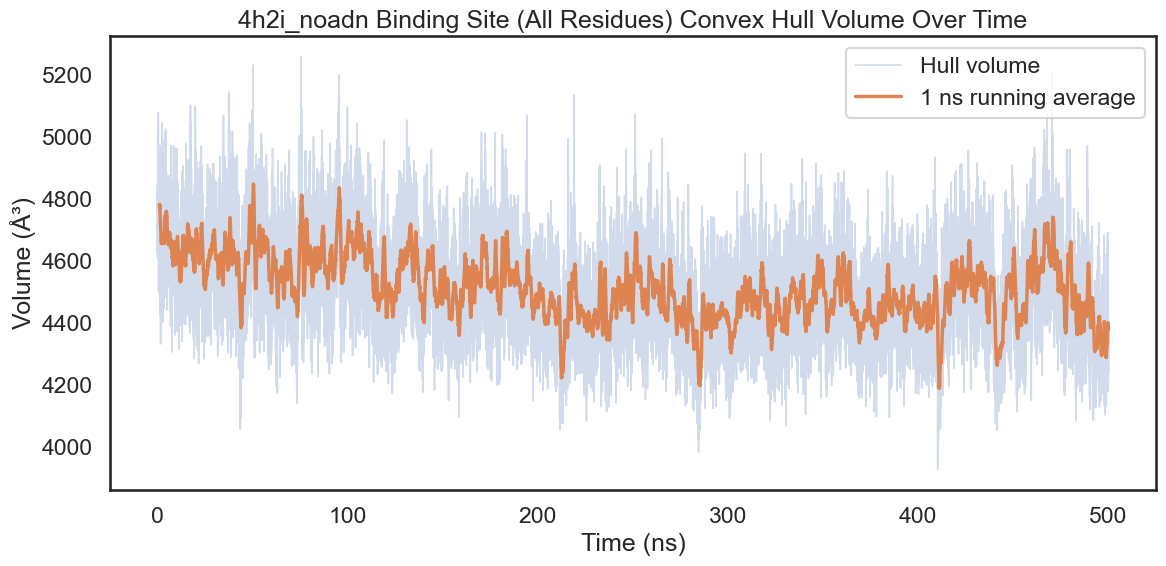

100%|██████████| 30003/30003 [00:50<00:00, 596.45it/s]


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/4h2g/unbiased/4h2g_Binding_Site_(All_Residues)_Convex_Hull_Volume_Over_Time.png


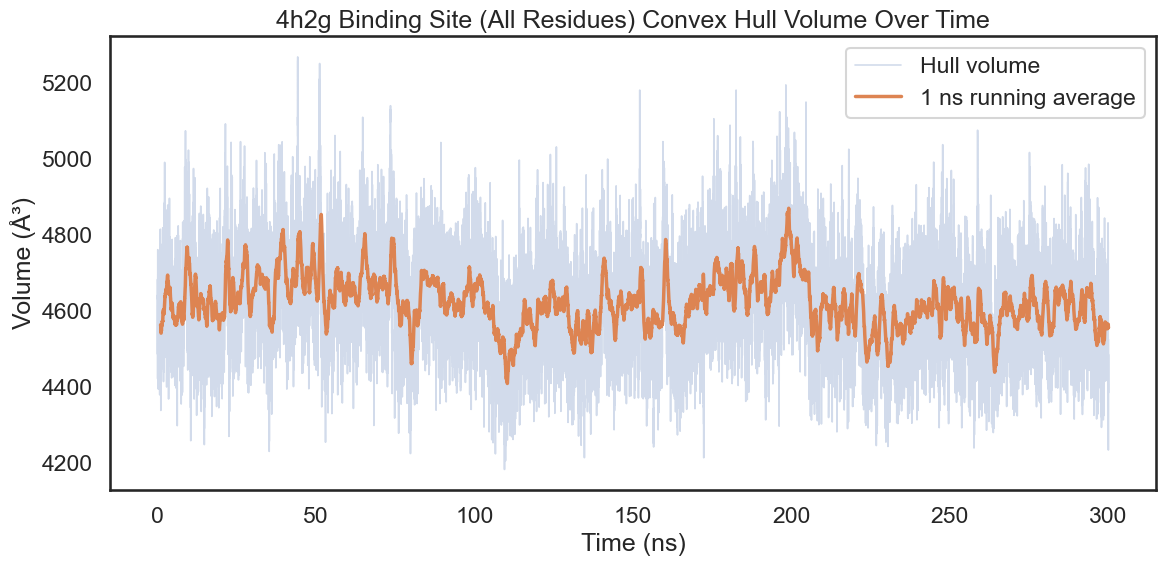

100%|██████████| 21892/21892 [00:39<00:00, 558.73it/s]


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/4h2g_noadn/unbiased/4h2g_noadn_Binding_Site_(All_Residues)_Convex_Hull_Volume_Over_Time.png


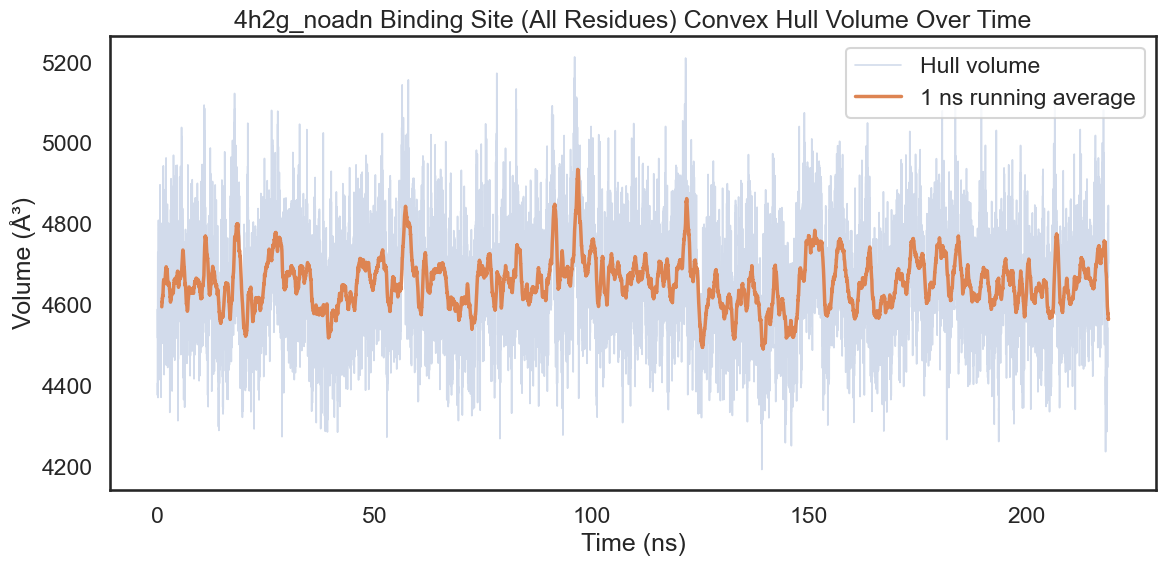

100%|██████████| 50006/50006 [01:16<00:00, 653.57it/s]


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/6tve/unbiased/6tve_Binding_Site_(All_Residues)_Convex_Hull_Volume_Over_Time.png


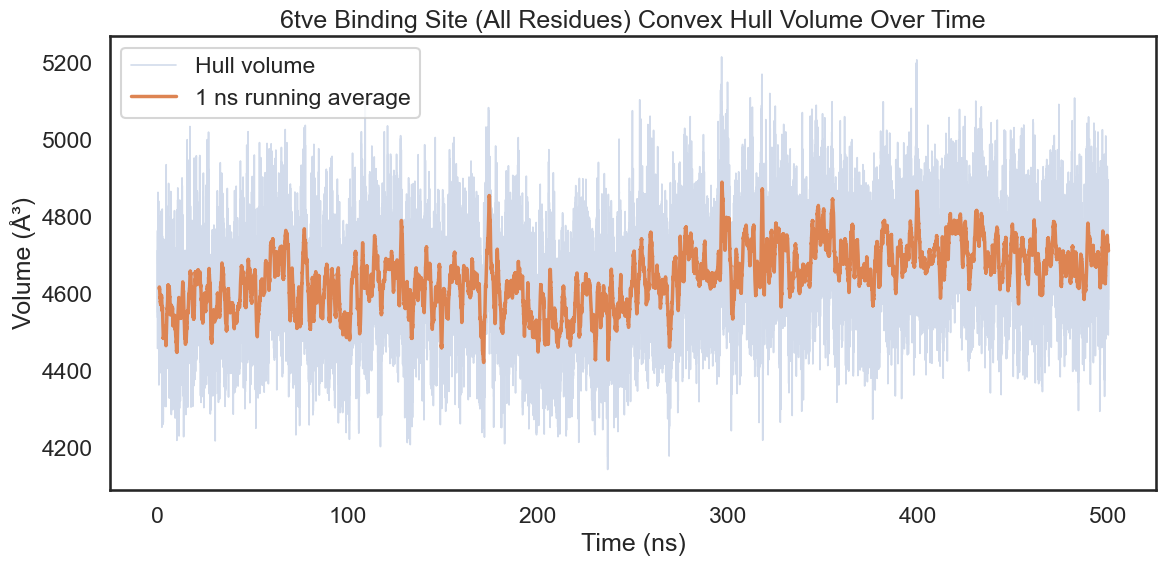

100%|██████████| 20002/20002 [00:31<00:00, 628.38it/s]


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/6twa/unbiased/6twa_Binding_Site_(All_Residues)_Convex_Hull_Volume_Over_Time.png


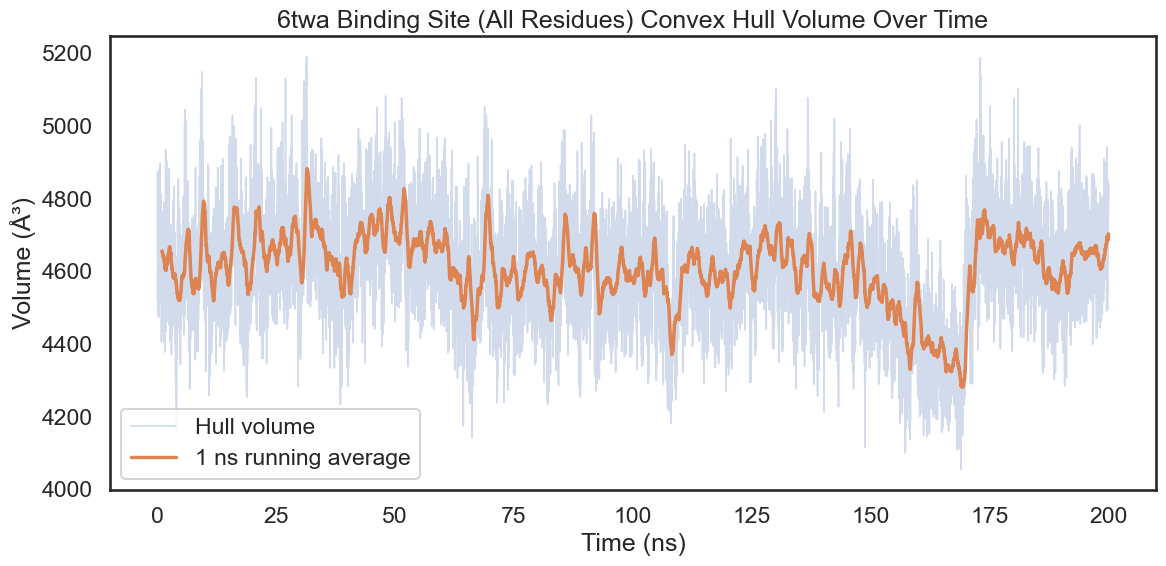

In [5]:
for name, traj in allosteric_bindingsite_trajectories.items():
    traj.plot_volume_over_time(title=f"{name} Binding Site (All Residues) Convex Hull Volume Over Time")

100%|██████████| 50005/50005 [01:30<00:00, 551.21it/s]


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/4h2i/unbiased/4h2i_Dimer_Interface_Convex_Hull_Volume_Over_Time.png


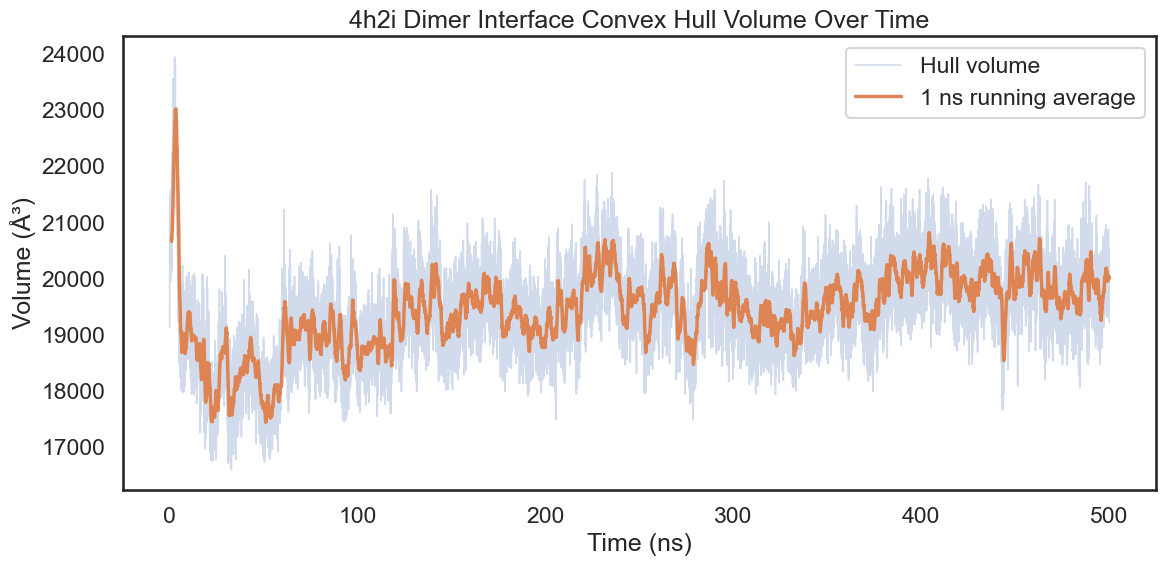

100%|██████████| 50006/50006 [01:29<00:00, 558.40it/s]


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/4h2i_noadn/unbiased/4h2i_noadn_Dimer_Interface_Convex_Hull_Volume_Over_Time.png


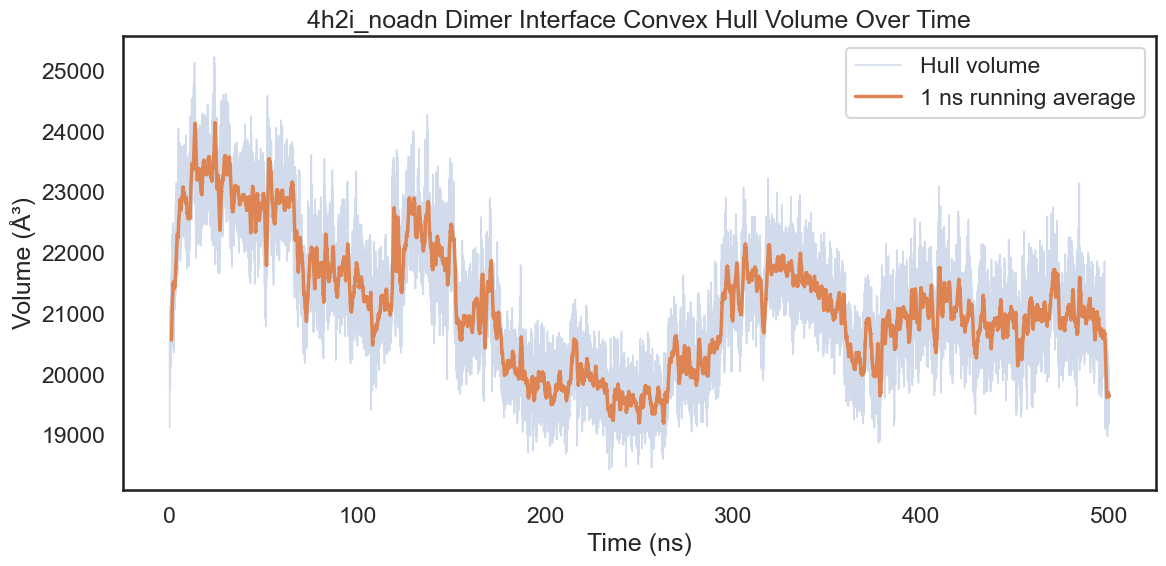

100%|██████████| 30003/30003 [00:54<00:00, 554.33it/s]


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/4h2g/unbiased/4h2g_Dimer_Interface_Convex_Hull_Volume_Over_Time.png


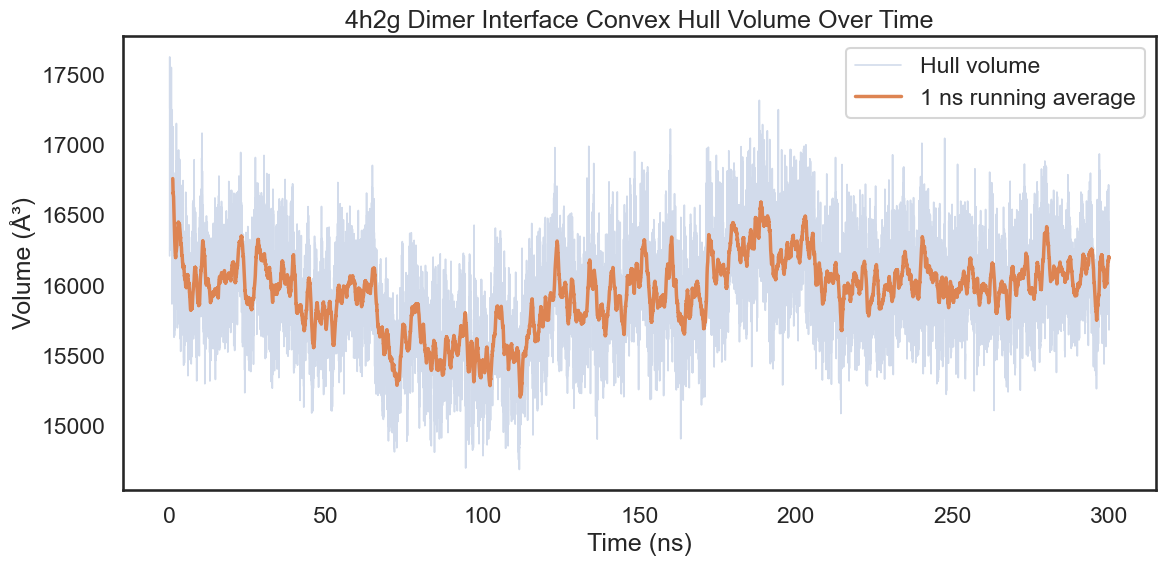

100%|██████████| 21892/21892 [00:38<00:00, 571.55it/s]


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/4h2g_noadn/unbiased/4h2g_noadn_Dimer_Interface_Convex_Hull_Volume_Over_Time.png


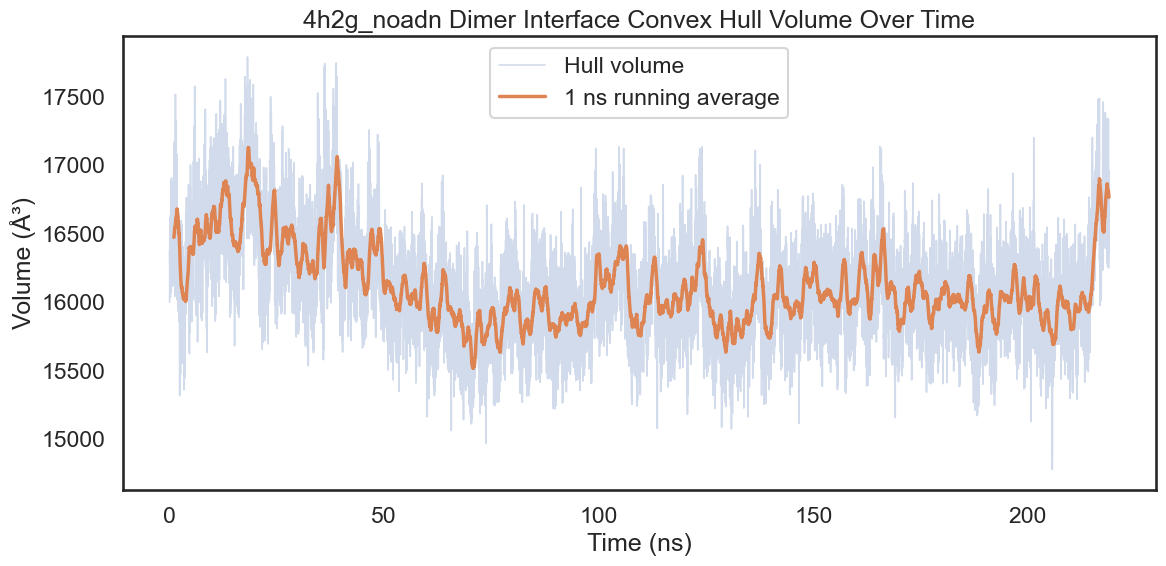

100%|██████████| 50006/50006 [01:29<00:00, 559.93it/s]


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/6tve/unbiased/6tve_Dimer_Interface_Convex_Hull_Volume_Over_Time.png


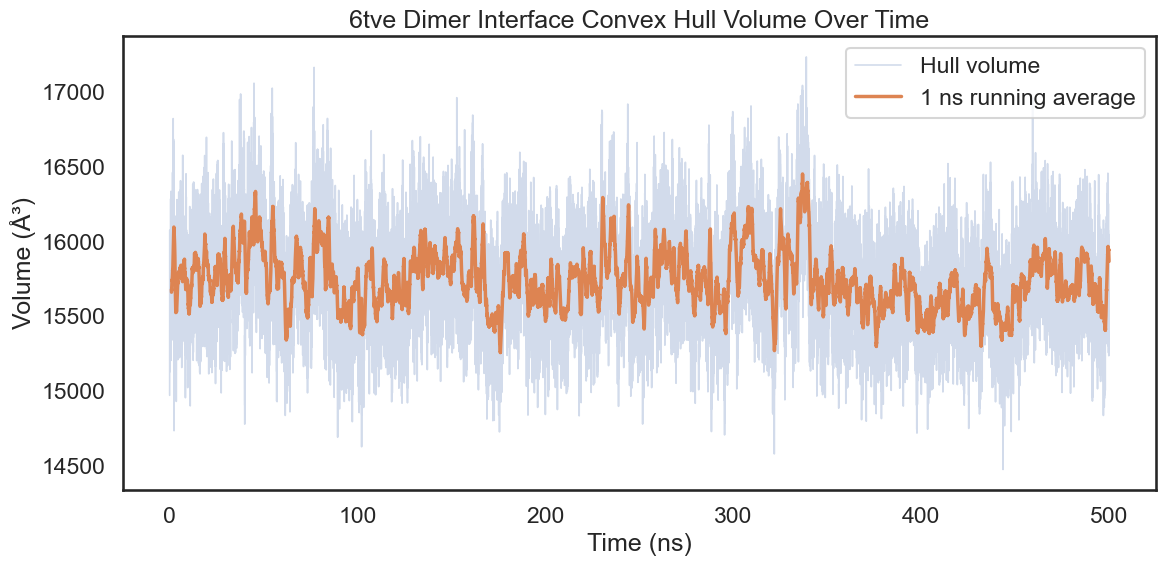

100%|██████████| 20002/20002 [00:33<00:00, 589.17it/s]


Plot saved to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/6twa/unbiased/6twa_Dimer_Interface_Convex_Hull_Volume_Over_Time.png


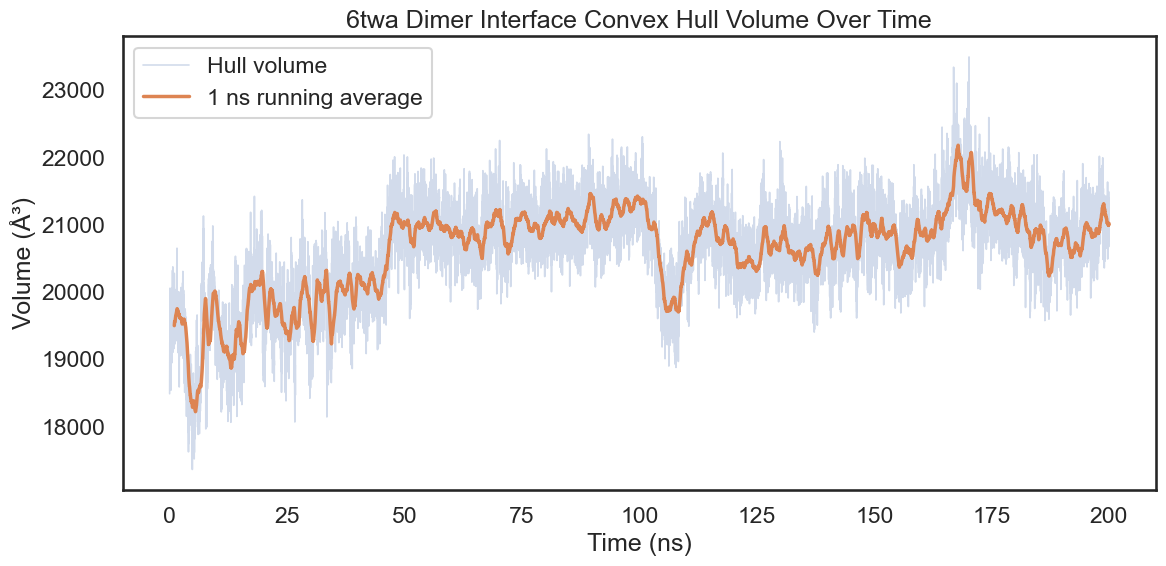

In [6]:
for name, traj in interface_trajectories.items():
    traj.plot_volume_over_time(title=f"{name} Dimer Interface Convex Hull Volume Over Time")

## Difference in dimer interface volume between open and closed structures
It can be observed that the closed (`6TWA`, `4H2I`) structures seem to have a larger dimer interface volume than the open-conformation protein (`6TVE`, `4H2G`).

In [17]:
allosteric_bindingsite_trajectories['4h2g'].write_system_frame_pdb(frame_index=5000)

Wrote system frame 5000 to PDB: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/4h2g/unbiased/frame_5000.pdb
Wrote hull PDB to: /Users/wes/Documents/bps/RP2/cd73_dualantagonist/MD/results/4h2g/unbiased/hull_frame_5000.pdb


/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'elements' Using default value of ' '
  warnings.warn(
/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'formalcharges' Using default value of '0'
  warnings.warn(
/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/MDAnalysis/coordinates/PDB.py:1336: UserWarning: Found missing chainIDs. Corresponding atoms will use value of 'X'
  warnings.warn(


## RMSD of allosteric binding site residues

In [ ]:
R = rms.RMSD(allobinding_4h2g.residue_atoms_only_heavy_sidechains)

array([1.83534708e-07, 9.85508967e-01, 8.73530922e-01, ...,
       9.00664186e-01, 9.47952373e-01, 9.78197268e-01], shape=(30003,))

# Autocorrelation time of allosteric binding site volumes
Grossfield et al. (2019, https://livecomsjournal.org/index.php/livecoms/article/view/v1i1e5067/913) discusses the implementation of autocorrelation time analysis to estimate the number of independent samples in a (time series) MD trajectory. 

Here, I implement this analysis to calculate the autocorrelation time to 1. estimate standard uncertainty of the allosteric binding pocket volumes, and 2. find out the number of samples with statistically independent volumes for docking (check that my MD simulation time is long enough to sample independent conformers)

**To-do: autocorrelation time of binding site RMSD**

In [13]:
def autocorrelation_time(series: np.ndarray[float], dt: float) -> float:
    n = len(series)
    series = series - np.mean(series)

    var = np.var(series)
    acf = np.zeros(n)

    for lag in range(n):
        x1 = series[:n - lag]
        x2 = series[lag:]
        acf[lag] = np.mean(x1 * x2) / var

    zeros = np.where(acf < 0)[0]
    cutoff = zeros[0] if len(zeros) > 0 else n

    tau_int = dt * (1 + 2*np.sum(acf[1:cutoff]))
    return tau_int

def effective_sample_size(series: np.ndarray[float], dt: float) -> float:
    tau_int = autocorrelation_time(series, dt)
    n = len(series)
    n_eff = n * dt / (2 * tau_int)
    return n_eff

def bootstrap_confidence_interval(series: np.ndarray[float], dt: float, n_bootstrap: int = 1000, confidence_level: float = 0.95) -> tuple[float, float]:
    n_eff = effective_sample_size(series, dt)
    n = len(series)
    indices = np.random.choice(n, size=(n_bootstrap, int(n_eff)), replace=True)
    bootstrap_means = np.array([np.mean(series[idx]) for idx in indices])
    lower_bound = np.percentile(bootstrap_means, (1 - confidence_level) / 2 * 100)
    upper_bound = np.percentile(bootstrap_means, (1 + confidence_level) / 2 * 100)
    return lower_bound, upper_bound


In [15]:
for name, traj in allosteric_bindingsite_trajectories.items():
    volumes = np.array([hull.volume for hull in traj.hulls])
    print(f"{name} - Allosteric Binding Pocket Volume Autocorrelation time: {autocorrelation_time(volumes, traj.universe.trajectory.dt)}")
    print(f"{name} - Effective sample size: {effective_sample_size(volumes, traj.universe.trajectory.dt)}")
    print(f"{name} - Mean and SEM: {np.mean(volumes)}, {np.std(volumes) / np.sqrt(effective_sample_size(volumes, traj.universe.trajectory.dt))}")
    print(f"{name} - 95% CI: {bootstrap_confidence_interval(volumes, traj.universe.trajectory.dt)}")
    print("\n")

4h2i - Allosteric Binding Pocket Volume Autocorrelation time: 37965.106710942244
4h2i - Effective sample size: 6.5856525020101735
4h2i - Mean and SEM: 4563.293745983524, 64.65373131961618
4h2i - 95% CI: (np.float64(4441.14389068725), np.float64(4699.547655720376))


4h2i_noadn - Allosteric Binding Pocket Volume Autocorrelation time: 30608.026836615518
4h2i_noadn - Effective sample size: 8.16877224182567
4h2i_noadn - Mean and SEM: 4511.47085902167, 51.831205564644975
4h2i_noadn - 95% CI: (np.float64(4412.9072439945385), np.float64(4612.908689766625))


4h2g - Allosteric Binding Pocket Volume Autocorrelation time: 3904.9555397148024
4h2g - Effective sample size: 38.41657055356802
4h2g - Mean and SEM: 4621.524375695344, 20.53488343862613
4h2g - 95% CI: (np.float64(4579.923222327407), np.float64(4660.729842218524))


4h2g_noadn - Allosteric Binding Pocket Volume Autocorrelation time: 537.0375715333303
4h2g_noadn - Effective sample size: 203.82186610794056
4h2g_noadn - Mean and SEM: 4656.27

In [16]:
for name, traj in interface_trajectories.items():
    volumes = np.array([hull.volume for hull in traj.hulls])
    print(f"{name} - Dimer Interface Volume Autocorrelation time: {autocorrelation_time(volumes, traj.universe.trajectory.dt)}")
    print(f"{name} - Effective sample size: {effective_sample_size(volumes, traj.universe.trajectory.dt)}")
    print(f"{name} - Mean and SEM: {np.mean(volumes)}, {np.std(volumes) / np.sqrt(effective_sample_size(volumes, traj.universe.trajectory.dt))}")
    print(f"{name} - 95% CI: {bootstrap_confidence_interval(volumes, traj.universe.trajectory.dt)}")
    print("\n")

4h2i - Dimer Interface Volume Autocorrelation time: 38614.52447216974
4h2i - Effective sample size: 6.4748952218794775
4h2i - Mean and SEM: 19442.998282147575, 307.84405182994954
4h2i - 95% CI: (np.float64(18828.04814348892), np.float64(20106.084602294282))


4h2i_noadn - Dimer Interface Volume Autocorrelation time: 68587.73946760819
4h2i_noadn - Effective sample size: 3.6454037112286115
4h2i_noadn - Mean and SEM: 21152.16045918052, 571.8569747902596
4h2i_noadn - 95% CI: (np.float64(19979.103550484302), np.float64(22423.14171742424))


4h2g - Dimer Interface Volume Autocorrelation time: 20181.77524987323
4h2g - Effective sample size: 7.433191487995701
4h2g - Mean and SEM: 15954.734456109698, 126.72968083637672
4h2g - 95% CI: (np.float64(15708.813716921044), np.float64(16212.45939610554))


4h2g_noadn - Dimer Interface Volume Autocorrelation time: 13572.239981214252
4h2g_noadn - Effective sample size: 8.064991493777512
4h2g_noadn - Mean and SEM: 16118.155852149404, 132.43235584738608
4h